## 1. Importación de librerías

Se importan las herramientas necesarias para cargar imágenes, crear los conjuntos de datos, entrenar el modelo y mostrar los resultados.

- `torch`: permite trabajar con tensores y realizar las operaciones del perceptrón.
- `ImageFolder`: carga imágenes organizadas en carpetas por clase.
- `DataLoader`: permite recorrer las imágenes durante el entrenamiento y la prueba.
- `transforms`: transforma las imágenes a escala de grises y tensores.
- `matplotlib`: permite mostrar las imágenes y los mapas de calor.

In [1]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

In [2]:
class perceptron():
    def __init__(self,n_inputs,n_outputs):
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs
        self.threshold = 0
        self.weights = []
        for i in range(self.n_outputs):
            self.weights.append(torch.zeros(n_inputs+1,1,dtype = torch.float32))
            
    def forward(self,x):
        output = []
        for i in range(self.n_outputs):
            if torch.matmul(x,self.weights[i])>self.threshold:
                output_prev = 1
            elif torch.matmul(x,self.weights[i])<-self.threshold:
                output_prev = -1
            else:
                output_prev = 0
            output.append(output_prev)
        return torch.tensor(output)

    def train(self,traindataloader,learning_rate=1, threshold=1):
        self.learning_rate = learning_rate
        self.threshold = threshold
        stop_condition = False
        epochs = 0
        while not(stop_condition):
            print('epochs', epochs)
            stop_condition = True
            for img, labels in iter(traindataloader):
                img_b = 2*((img>0.5)*1.0)-1
                t = torch.tensor([-1,-1,-1])
                x_i = torch.concat([torch.ones(1), img_b.flatten()]).unsqueeze(axis=0)
                t[labels.item()]=1
                y = self.forward(x_i)
                for i in range(self.n_outputs):
                    if y[i].item()!=t[i].item():
                        self.weights[i][1:] = self.weights[i][1:]+self.learning_rate*(torch.transpose(x_i,0,1)[1:]*t[i])
                        self.weights[i][0] = self.weights[i][0] + self.learning_rate*t[i]
                        stop_condition = False
            epochs+=1

In [3]:
torch.manual_seed(0)
torch.cuda.manual_seed(0)

In [4]:
train_directory = "dataset_JKL/train/"
test_directory = "dataset_JKL/test/"

In [5]:
transform_train = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor()
])

In [6]:
train_dataset = ImageFolder(train_directory,transform_train)
test_dataset = ImageFolder(test_directory,transform_test)

In [7]:
train_dataset.classes

['J', 'K', 'L']

In [8]:
train_dataset.class_to_idx

{'J': 0, 'K': 1, 'L': 2}

In [9]:
train_dataset, test_dataset

(Dataset ImageFolder
     Number of datapoints: 30
     Root location: dataset_JKL/train/
     StandardTransform
 Transform: Compose(
                Grayscale(num_output_channels=1)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 30
     Root location: dataset_JKL/test/
     StandardTransform
 Transform: Compose(
                Grayscale(num_output_channels=1)
                ToTensor()
            ))

In [10]:
(2*((train_dataset[1][0]>0.5)*1.0)-1)

tensor([[[ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
         [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
         [ 1.,  1., -1., -1., -1.,  1.,  1.,  1.],
         [ 1.,  1.,  1., -1.,  1.,  1.,  1.,  1.],
         [ 1.,  1.,  1., -1.,  1.,  1.,  1.,  1.],
         [ 1.,  1., -1., -1.,  1.,  1.,  1.,  1.],
         [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
         [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.]]])

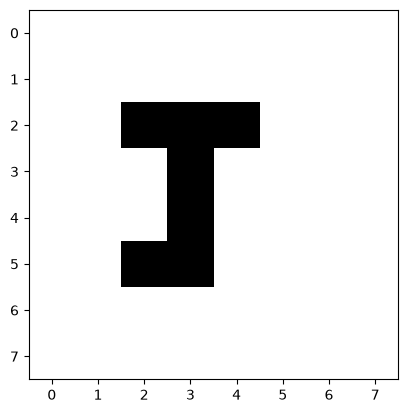

In [11]:
plt.imshow(train_dataset[1][0].permute(dims=[1,2,0]),cmap='gray')
plt.show()

In [12]:
BATCH_SIZE = 1
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle = True)
test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle = False)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x254d4d0bad0>,
 <torch.utils.data.dataloader.DataLoader at 0x254d4d85990>)

In [13]:
imgtest = list(iter(train_dataloader))[0][0].squeeze(axis=0)

In [14]:
Perceptron1 = perceptron(n_inputs=64,n_outputs=3)

In [15]:
Perceptron1.train(train_dataloader, learning_rate = 0.01)

epochs 0
epochs 1
epochs 2
epochs 3
epochs 4
epochs 5
epochs 6
epochs 7
epochs 8
epochs 9
epochs 10
epochs 11
epochs 12
epochs 13
epochs 14
epochs 15
epochs 16
epochs 17
epochs 18
epochs 19
epochs 20
epochs 21
epochs 22
epochs 23
epochs 24
epochs 25
epochs 26
epochs 27
epochs 28
epochs 29
epochs 30
epochs 31
epochs 32
epochs 33
epochs 34
epochs 35
epochs 36
epochs 37
epochs 38
epochs 39
epochs 40
epochs 41
epochs 42
epochs 43
epochs 44


In [16]:
indice_clase = 0

Letra seleccionada: L
Salida: tensor([-1,  0,  0])
Predicción: K


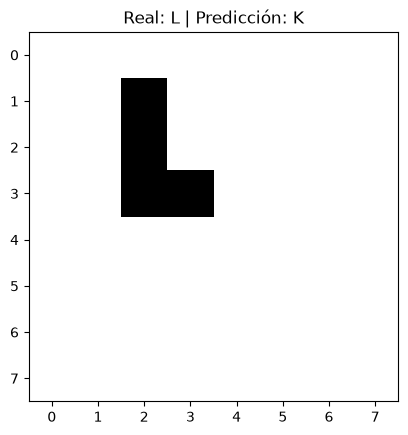

In [29]:
clase = train_dataset.classes[indice_clase]

indices_clase = [
    i
    for i, (_, etiqueta) in enumerate(test_dataset.samples)
    if etiqueta == indice_clase
]

indice = indices_clase[
    torch.randint(0, len(indices_clase), (1,)).item()
]

ruta = test_dataset.samples[indice][0]
real_label = test_dataset.samples[indice][1]

img = plt.imread(ruta)

if img.ndim == 3:
    img = img[:, :, 0]

input = torch.concat([
    torch.ones(1),
    torch.tensor(img).flatten()
]).unsqueeze(axis=0)

input = 2 * ((input > 0.5) * 1.0) - 1

output = Perceptron1.forward(input)

label = train_dataset.classes[torch.argmax(output).item()]

print("Letra seleccionada:", clase)
print("Salida:", output)
print("Predicción:", label)

plt.imshow(img, cmap="gray")
plt.title("Real: " + clase + " | Predicción: " + label)
plt.show()

indice_clase = (indice_clase + 1) % len(test_dataset.classes)

In [18]:
correctas = 0

for img, label in test_dataloader:

    input = torch.concat([
        torch.ones(1),
        img.flatten()
    ]).unsqueeze(axis=0)

    input = 2*((input>0.5)*1.0)-1

    output = Perceptron1.forward(input)

    prediccion = torch.argmax(output).item()

    print(
        "Real:",
        test_dataset.classes[label.item()],
        "| Predicción:",
        test_dataset.classes[prediccion]
    )

    if prediccion == label.item():
        correctas += 1


print("Correctas:", correctas)
print("Total:", len(test_dataset))
print(
    "Exactitud:",
    correctas / len(test_dataset) * 100,
    "%"
)

Real: J | Predicción: J
Real: J | Predicción: J
Real: J | Predicción: J
Real: J | Predicción: J
Real: J | Predicción: J
Real: J | Predicción: L
Real: J | Predicción: J
Real: J | Predicción: K
Real: J | Predicción: L
Real: J | Predicción: L
Real: K | Predicción: L
Real: K | Predicción: L
Real: K | Predicción: L
Real: K | Predicción: K
Real: K | Predicción: L
Real: K | Predicción: L
Real: K | Predicción: J
Real: K | Predicción: J
Real: K | Predicción: J
Real: K | Predicción: J
Real: L | Predicción: L
Real: L | Predicción: K
Real: L | Predicción: K
Real: L | Predicción: K
Real: L | Predicción: J
Real: L | Predicción: K
Real: L | Predicción: L
Real: L | Predicción: J
Real: L | Predicción: L
Real: L | Predicción: J
Correctas: 10
Total: 30
Exactitud: 33.33333333333333 %


In [19]:
data = (
    Perceptron1.weights[0][1:]
    + Perceptron1.weights[0][0]
)

minval = min(data)

data = data - minval

maxval = max(data)

if maxval.item() != 0:
    data = data / maxval

data

tensor([[0.5231],
        [0.4154],
        [0.5692],
        [0.3538],
        [0.5538],
        [0.2923],
        [0.2308],
        [0.5538],
        [0.5231],
        [0.5077],
        [0.5538],
        [0.0000],
        [0.6923],
        [0.1077],
        [0.2615],
        [0.5846],
        [0.5231],
        [0.5846],
        [0.5385],
        [0.0462],
        [0.3846],
        [0.5231],
        [0.5846],
        [0.5077],
        [0.5231],
        [0.6000],
        [1.0000],
        [0.2769],
        [0.6000],
        [0.6000],
        [0.5077],
        [0.5077],
        [0.5231],
        [0.5692],
        [0.6615],
        [0.2154],
        [0.2769],
        [0.2769],
        [0.4000],
        [0.5077],
        [0.5231],
        [0.6154],
        [0.3538],
        [0.4923],
        [0.3231],
        [0.5231],
        [0.6769],
        [0.7077],
        [0.5231],
        [0.5231],
        [0.4154],
        [0.6462],
        [0.3538],
        [0.0308],
        [0.5077],
        [0

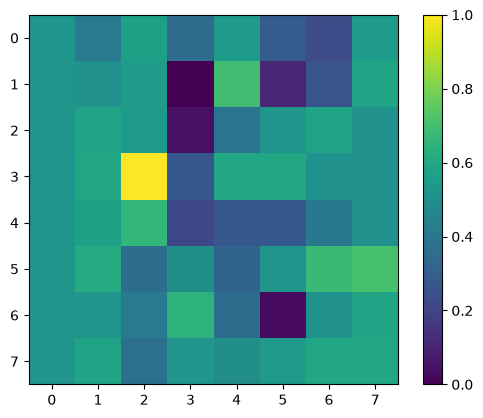

In [20]:
plt.imshow(
    data.reshape((8,8))
)

plt.colorbar()
plt.show()

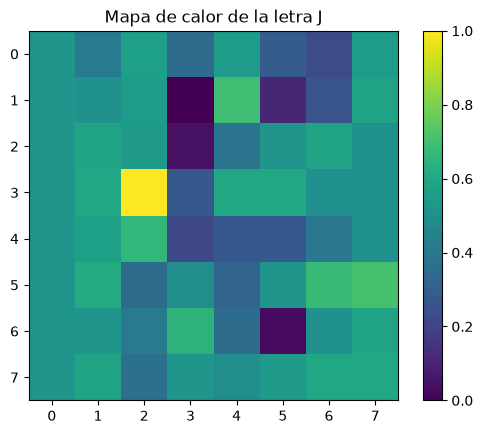

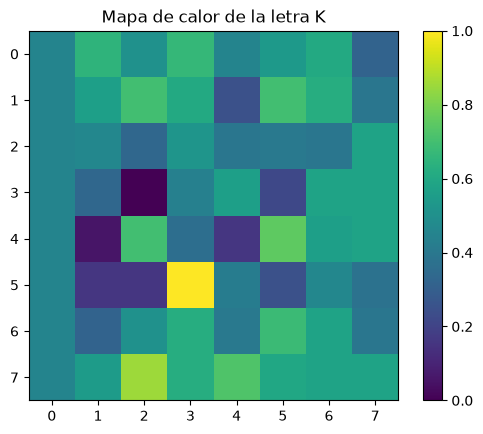

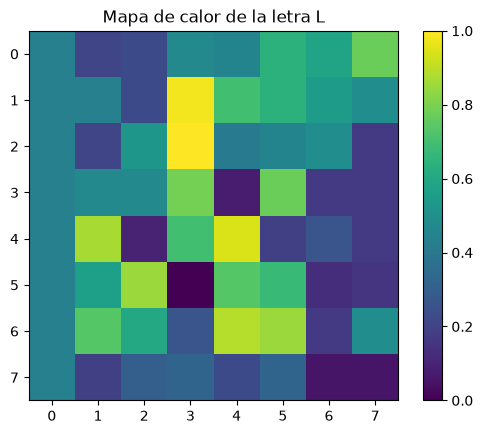

In [21]:
for i in range(3):

    data = (
        Perceptron1.weights[i][1:]
        + Perceptron1.weights[i][0]
    )

    minval = min(data)
    data = data - minval

    maxval = max(data)

    if maxval.item() != 0:
        data = data / maxval

    plt.figure()

    plt.imshow(
        data.reshape(8, 8)
    )

    plt.title(
        "Mapa de calor de la letra "
        + train_dataset.classes[i]
    )

    plt.colorbar()
    plt.show()